### **Zachłanne kolorowanie grafu, degeneracja i liczba chromatyczna

Kolorowanie grafu polega na przypisaniu kolorów do wierzchołków w taki sposób, aby żadne dwa sąsiednie wierzchołki nie miały tego samego koloru. Jest to klasyczne zagadnienie teorii grafów oraz optymalizacji dyskretnej.

Problem ten ma wiele zastosowań praktycznych, na przykład w układaniu planów zajęć, przydzielaniu zasobów, harmonogramowaniu zadań oraz w problemach związanych z sieciami komputerowymi.

W projekcie porówniono dwa podejścia:

- algorytm zachłanny w porządku SL (Smallest Last),
- wyznaczanie liczby chromatycznej metodą dokładną.

Algorytm zachłanny działa szybko, ale nie zawsze daje wynik optymalny. Liczba chromatyczna jest natomiast minimalną liczbą kolorów potrzebną do poprawnego pokolorowania grafu.


### **Reprezentacja grafu

Graf przechowywany jest w postaci listy sąsiedztwa. Dla każdego wierzchołka zapisujemy listę jego sąsiadów.

Taka reprezentacja jest wygodna, czytelna i dobrze nadaje się do implementacji algorytmów kolorowania.

W projekcie można wczytać graf od użytkownika, ale dla przykładu działania używane są gotowe grafy zapisane bezpośrednio w kodzie.

In [11]:
import networkx as nx
import matplotlib.pyplot as plt


def read_graph():
    n = int(input("Podaj liczbę wierzchołków: "))
    m = int(input("Podaj liczbę krawędzi: "))

    adj = [[] for _ in range(n)]

    print("Podawaj krawędzie w formacie: u v")
    print("Wierzchołki numerujemy od 0 do n-1")

    for i in range(m):
        u, v = map(int, input(f"Krawędź {i + 1}: ").split())

        if v not in adj[u]:
            adj[u].append(v)
        if u not in adj[v]:
            adj[v].append(u)

    return adj


def print_coloring(colors):
    for v, c in enumerate(colors):
        print(f"Wierzchołek {v} -> kolor {c}")


def draw_graph(adj, title="Graf"):
    G = nx.Graph()
    for v, neighbors in enumerate(adj):
        for u in neighbors:
            G.add_edge(v, u)

    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=1000, font_size=12)
    plt.title(title)
    plt.show()


def greedy_coloring_order(adj, order):
    """
    Zachłanne kolorowanie grafu w zadanej kolejności wierzchołków.
    Dla każdego wierzchołka wybierany jest najmniejszy możliwy kolor.
    """
    n = len(adj)
    colors = [-1] * n

    for v in order:
        used_colors = {colors[u] for u in adj[v] if colors[u] != -1}
        color = 0

        while color in used_colors:
            color += 1

        colors[v] = color

    return colors


def largest_first_order(adj):
    """
    Porządek LF (Largest First):
    najpierw wierzchołki o największym stopniu.
    """
    return sorted(range(len(adj)), key=lambda v: len(adj[v]), reverse=True)


def smallest_last_order(adj):
    """
    Porządek SL (Smallest Last):
    usuwamy kolejno wierzchołki o najmniejszym stopniu,
    a potem odwracamy otrzymaną kolejność.
    """
    n = len(adj)
    remaining = set(range(n))
    degrees = [len(adj[v]) for v in range(n)]
    removal_order = []

    while remaining:
        v = min(remaining, key=lambda x: degrees[x])
        removal_order.append(v)
        remaining.remove(v)

        for u in adj[v]:
            if u in remaining:
                degrees[u] -= 1

    return list(reversed(removal_order))


def degeneracy(adj):
    """
    Degeneracja grafu:
    d(G) = max_{H subseteq G} delta(H)
    """
    n = len(adj)
    remaining = set(range(n))
    degrees = [len(adj[v]) for v in range(n)]
    d = 0

    while remaining:
        v = min(remaining, key=lambda x: degrees[x])
        d = max(d, degrees[v])
        remaining.remove(v)

        for u in adj[v]:
            if u in remaining:
                degrees[u] -= 1

    return d


def greedy_coloring_lf(adj):
    """
    Kolorowanie zachłanne w porządku LF.
    """
    order = largest_first_order(adj)
    return greedy_coloring_order(adj, order)


def greedy_coloring_sl(adj):
    """
    Kolorowanie zachłanne w porządku SL.
    """
    order = smallest_last_order(adj)
    return greedy_coloring_order(adj, order)


def is_safe(v, color, colors, adj):
    """
    Sprawdza, czy można przypisać wierzchołkowi v kolor color.
    Kolor jest poprawny tylko wtedy, gdy żaden sąsiad nie ma tego samego koloru.
    """
    for u in adj[v]:
        if colors[u] == color:
            return False
    return True


def can_color_with_k(adj, k):
    """
    Sprawdza, czy graf da się pokolorować używając maksymalnie k kolorów.
    Jeśli tak, zwraca listę kolorów, w przeciwnym razie None.
    """
    n = len(adj)
    colors = [-1] * n

    def backtrack(v):
        if v == n:
            return True

        for c in range(k):
            if is_safe(v, c, colors, adj):
                colors[v] = c
                if backtrack(v + 1):
                    return True
                colors[v] = -1

        return False

    if backtrack(0):
        return colors
    return None


def chromatic_number(adj, upper_bound=None):
    """
    Wyznacza liczbę chromatyczną metodą dokładną.
    upper_bound pozwala ograniczyć liczbę sprawdzanych kolorów
    (np. do wyniku algorytmu zachłannego).
    """
    limit = len(adj) if upper_bound is None else upper_bound

    for k in range(1, limit + 1):
        colors = can_color_with_k(adj, k)
        if colors is not None:
            return k, colors

    return None, None

### Algorytm zachłanny

Algorytm zachłanny przegląda wierzchołki w ustalonej kolejności i dla każdego z nich wybiera najmniejszy dostępny kolor, który nie występuje u jego sąsiadów.

W projekcie zastosowano porządek SL (Smallest Last). Najpierw usuwa się kolejno wierzchołki o najmniejszym stopniu, a następnie koloruje się graf w odwrotnej kolejności.

Zaletą algorytmu zachłannego jest prostota i szybkość działania. Wadą jest to, że nie gwarantuje znalezienia minimalnej liczby kolorów.

### Liczba chromatyczna

Liczba chromatyczna grafu to najmniejsza liczba kolorów, która wystarcza do poprawnego pokolorowania wszystkich wierzchołków.

Do jej wyznaczenia użyto metody dokładnej opartej na backtrackingu. Program sprawdza kolejno, czy graf da się pokolorować 1 kolorem, potem 2 kolorami, następnie 3 i tak dalej.

Pierwsza wartość, dla której kolorowanie staje się możliwe, jest liczbą chromatyczną grafu.

W projekcie wynik algorytmu zachłannego porównywany jest z wynikiem optymalnym.

In [12]:
# Przykładowy graf:
# 0 --- 3
#       |
# 1 --- 2

adj1 = [
    [3],      # 0
    [2],      # 1
    [1, 3],   # 2
    [0, 2]    # 3
]

print("Przykład 1")
print("Lista sąsiedztwa:")
print(adj1)

greedy1 = greedy_coloring_sl(adj1)
greedy_colors_used1 = max(greedy1) + 1
d1 = degeneracy(adj1)

print("\nKolorowanie zachłanne (SL):")
print_coloring(greedy1)
print(f"\nLiczba kolorów użyta przez algorytm zachłanny: {greedy_colors_used1}")
print(f"Degeneracja grafu: {d1}")
print(f"Górne ograniczenie z twierdzenia: d(G) + 1 = {d1 + 1}")

chi1, exact_colors1 = chromatic_number(adj1, upper_bound=greedy_colors_used1)

print("\nKolorowanie minimalne (dokładne):")
print_coloring(exact_colors1)

print("\nPorównanie wyników:")
print(f"Liczba kolorów w algorytmie zachłannym: {greedy_colors_used1}")
print(f"Liczba chromatyczna grafu: {chi1}")

Przykład 1
Lista sąsiedztwa:
[[3], [2], [1, 3], [0, 2]]

Kolorowanie zachłanne (SL):
Wierzchołek 0 -> kolor 1
Wierzchołek 1 -> kolor 0
Wierzchołek 2 -> kolor 1
Wierzchołek 3 -> kolor 0

Liczba kolorów użyta przez algorytm zachłanny: 2
Degeneracja grafu: 1
Górne ograniczenie z twierdzenia: d(G) + 1 = 2

Kolorowanie minimalne (dokładne):
Wierzchołek 0 -> kolor 0
Wierzchołek 1 -> kolor 1
Wierzchołek 2 -> kolor 0
Wierzchołek 3 -> kolor 1

Porównanie wyników:
Liczba kolorów w algorytmie zachłannym: 2
Liczba chromatyczna grafu: 2


### Analiza wyników

W tym przykładzie program porównuje wynik algorytmu zachłannego z wynikiem dokładnym. Dodatkowo obliczana jest degeneracja grafu, która daje teoretyczne ograniczenie na liczbę potrzebnych kolorów.

Jeżeli algorytm zachłanny użyje tylu samo kolorów co liczba chromatyczna, oznacza to, że w danym przykładzie znalazł rozwiązanie optymalne. Jeśli użyje więcej kolorów, pokazuje to, że metoda zachłanna daje tylko przybliżenie.



Przykład 2
Lista sąsiedztwa:
[[1, 4], [0, 2], [1, 3], [2, 4], [0, 3]]


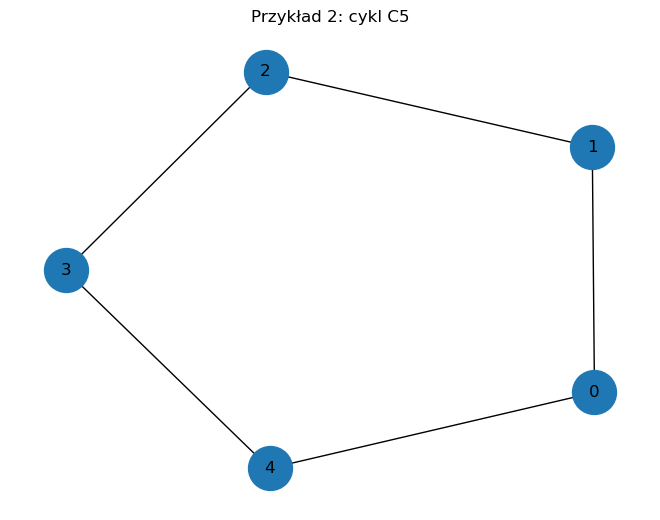


Kolorowanie zachłanne (SL):
Wierzchołek 0 -> kolor 2
Wierzchołek 1 -> kolor 1
Wierzchołek 2 -> kolor 0
Wierzchołek 3 -> kolor 1
Wierzchołek 4 -> kolor 0

Liczba kolorów użyta przez algorytm zachłanny: 3
Degeneracja grafu: 2
Górne ograniczenie z twierdzenia: d(G) + 1 = 3

Kolorowanie minimalne (dokładne):
Wierzchołek 0 -> kolor 0
Wierzchołek 1 -> kolor 1
Wierzchołek 2 -> kolor 0
Wierzchołek 3 -> kolor 1
Wierzchołek 4 -> kolor 2

Porównanie wyników:
Liczba kolorów w algorytmie zachłannym: 3
Liczba chromatyczna grafu: 3


In [13]:
# Przykład 2: cykl pięciowierzchołkowy C5
# Jest to graf, w którym liczba chromatyczna wynosi 3.

adj2 = [
    [1, 4],   # 0
    [0, 2],   # 1
    [1, 3],   # 2
    [2, 4],   # 3
    [0, 3]    # 4
]

print("\n\nPrzykład 2")
print("Lista sąsiedztwa:")
print(adj2)

draw_graph(adj2, title="Przykład 2: cykl C5")

greedy2 = greedy_coloring_sl(adj2)
greedy_colors_used2 = max(greedy2) + 1
d2 = degeneracy(adj2)

print("\nKolorowanie zachłanne (SL):")
print_coloring(greedy2)
print(f"\nLiczba kolorów użyta przez algorytm zachłanny: {greedy_colors_used2}")
print(f"Degeneracja grafu: {d2}")
print(f"Górne ograniczenie z twierdzenia: d(G) + 1 = {d2 + 1}")

chi2, exact_colors2 = chromatic_number(adj2, upper_bound=greedy_colors_used2)

print("\nKolorowanie minimalne (dokładne):")
print_coloring(exact_colors2)

print("\nPorównanie wyników:")
print(f"Liczba kolorów w algorytmie zachłannym: {greedy_colors_used2}")
print(f"Liczba chromatyczna grafu: {chi2}")

In [14]:
# Przykład 3
#      1
#     / \
#    /   \
#   0-----2
#   |      \
#   |       \
#   4-------3
#   |
#   |
#   5

adj3 = [
    [1, 2, 4],  # 0
    [0, 2],     # 1
    [0, 1, 3],  # 2
    [2, 4],     # 3
    [0, 3, 5],  # 4
    [4]         # 5
]

print("\n\nPrzykład 3")
print("Lista sąsiedztwa:")
print(adj3)

greedy3 = greedy_coloring_sl(adj3)
greedy_colors_used3 = max(greedy3) + 1
d3 = degeneracy(adj3)

print("\nKolorowanie zachłanne (SL):")
print_coloring(greedy3)
print(f"\nLiczba kolorów użyta przez algorytm zachłanny: {greedy_colors_used3}")
print(f"Degeneracja grafu: {d3}")
print(f"Górne ograniczenie z twierdzenia: d(G) + 1 = {d3 + 1}")

chi3, exact_colors3 = chromatic_number(adj3, upper_bound=greedy_colors_used3)

print("\nKolorowanie minimalne (dokładne):")
print_coloring(exact_colors3)

print("\nPorównanie wyników:")
print(f"Liczba kolorów w algorytmie zachłannym: {greedy_colors_used3}")
print(f"Liczba chromatyczna grafu: {chi3}")



Przykład 3
Lista sąsiedztwa:
[[1, 2, 4], [0, 2], [0, 1, 3], [2, 4], [0, 3, 5], [4]]

Kolorowanie zachłanne (SL):
Wierzchołek 0 -> kolor 1
Wierzchołek 1 -> kolor 2
Wierzchołek 2 -> kolor 0
Wierzchołek 3 -> kolor 1
Wierzchołek 4 -> kolor 0
Wierzchołek 5 -> kolor 1

Liczba kolorów użyta przez algorytm zachłanny: 3
Degeneracja grafu: 2
Górne ograniczenie z twierdzenia: d(G) + 1 = 3

Kolorowanie minimalne (dokładne):
Wierzchołek 0 -> kolor 0
Wierzchołek 1 -> kolor 1
Wierzchołek 2 -> kolor 2
Wierzchołek 3 -> kolor 0
Wierzchołek 4 -> kolor 1
Wierzchołek 5 -> kolor 0

Porównanie wyników:
Liczba kolorów w algorytmie zachłannym: 3
Liczba chromatyczna grafu: 3




Przykład 4
Lista sąsiedztwa:
[[1, 3, 4, 5], [0, 3, 5], [3, 4, 5], [0, 1, 2, 4], [0, 2, 3], [0, 1, 2]]


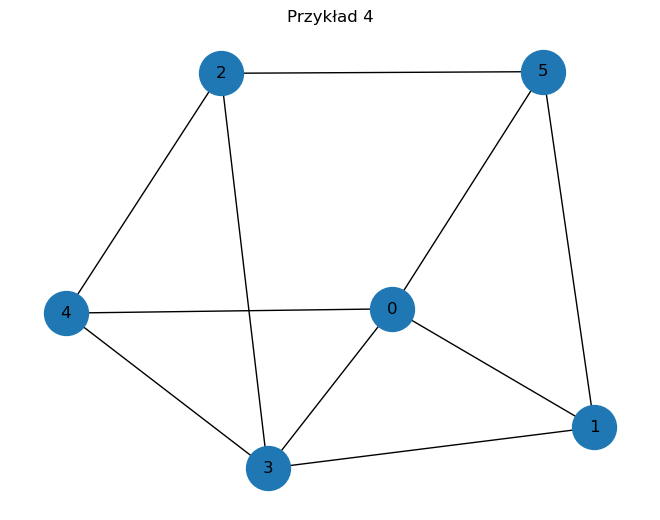


Kolorowanie zachłanne (SL):
Wierzchołek 0 -> kolor 2
Wierzchołek 1 -> kolor 3
Wierzchołek 2 -> kolor 2
Wierzchołek 3 -> kolor 1
Wierzchołek 4 -> kolor 0
Wierzchołek 5 -> kolor 0

Degeneracja grafu: 3
Górne ograniczenie: d(G) + 1 = 4

Kolorowanie minimalne (dokładne):
Wierzchołek 0 -> kolor 0
Wierzchołek 1 -> kolor 1
Wierzchołek 2 -> kolor 0
Wierzchołek 3 -> kolor 2
Wierzchołek 4 -> kolor 1
Wierzchołek 5 -> kolor 2

Porównanie wyników:
Liczba kolorów w algorytmie zachłannym: 4
Liczba chromatyczna grafu: 3


In [15]:
# Przykład 4
#
# 0 ----- 1
# |\     /|
# | \   / |
# |  \ /  |
# |   X   |
# |  / \  |
# | /   \ |
# |/     \|
# 4 ----- 3
#  \     /
#   \   /
#     2
#
# Dla tego grafu:
# kolorowanie zachłanne SL -> 4 kolory
# liczba chromatyczna -> 3

adj4 = [
    [1, 3, 4, 5],   # 0
    [0, 3, 5],      # 1
    [3, 4, 5],      # 2
    [0, 1, 2, 4],   # 3
    [0, 2, 3],      # 4
    [0, 1, 2]       # 5
]

print("\n\nPrzykład 4")
print("Lista sąsiedztwa:")
print(adj4)

draw_graph(adj4, title="Przykład 4")

greedy4 = greedy_coloring_sl(adj4)

print("\nKolorowanie zachłanne (SL):")
print_coloring(greedy4)

greedy_colors_used4 = max(greedy4) + 1

d4 = degeneracy(adj4)
print(f"\nDegeneracja grafu: {d4}")
print(f"Górne ograniczenie: d(G) + 1 = {d4 + 1}")

chi4, exact_colors4 = chromatic_number(
    adj4,
    upper_bound=greedy_colors_used4
)

print("\nKolorowanie minimalne (dokładne):")
print_coloring(exact_colors4)

print("\nPorównanie wyników:")
print(f"Liczba kolorów w algorytmie zachłannym: {greedy_colors_used4}")
print(f"Liczba chromatyczna grafu: {chi4}")

### Podsumowanie

W projekcie pokazano dwa sposoby kolorowania grafu: szybki algorytm zachłanny oraz metodę dokładną wyznaczającą liczbę chromatyczną.

Zastosowanie porządku SL poprawia działanie algorytmu zachłannego i wiąże się z pojęciem degeneracji grafu. Metoda dokładna pozwala natomiast sprawdzić rzeczywistą liczbę chromatyczną i porównać ją z wynikiem heurystyki.

Projekt łączy więc podejście praktyczne i teoretyczne: szybkie kolorowanie przybliżone, dokładne wyznaczanie optimum oraz zależność między degeneracją a liczbą chromatyczną.